## 4) Eddy and non-eddy intensity calculation

**Input: output from 2_preprocess_eddies.ipynb and daily FKE .zarr file**

**Output: .nc file of the eddy contribution to FKE**

First, background (non-eddy) intensity is calculated. Later eddy intensity.


In [1]:
import numpy as np
import xarray as xr
import dask
import dask.array as da
from dask.distributed import Client, LocalCluster
from matplotlib.path import Path
import os
import cv2
import zarr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import copy


**Read in data**

In [2]:
eke_path = "/scratch/b/b382615/eddies/"
model = "ICON"
icon_eke = xr.open_zarr(eke_path + "ICON_hist_GS.zarr", chunks={})



print(icon_eke)

FileNotFoundError: /scratch/b/b382615/eddies/ICON_hist_GS.zarr does not exist

In [6]:
track_path = "/work/bk1377/b382618/model_eddy_eval/historical/icon/eddyTracks/"
sorted_zarr = "/scratch/b/b382618/eeke/" + "consolidated_tracks_reindexed_"+model+"_final.zarr"

### 1) NON-EEDY EKE NAN

In [5]:
lons = icon_eke.lon.values
lats = icon_eke.lat.values

for the 22y this takes abuot 2-3h. 

this step creates daily masks with all eddies in the field.

In [6]:

# 1. Access the contour data
path = "/scratch/b/b382618/eeke/" + "consolidated_tracks_reindexed_" + model + "_final.zarr" 
ds_tracks = zarr.open(path, mode='r')

# 2. Setup output Zarr parameters
start_day = 0
end_day = 8034 
num_days = (end_day - start_day) + 1

lons = icon_eke.lon.values
lats = icon_eke.lat.values
nlat, nlon = len(lats), len(lons)

zarr_path = "/scratch/b/b382618/eeke/NAN/non_eddy_mask"+ model +".zarr"

# Create the Zarr dataset using float32 to support NaN values
mask_zarr = zarr.open(
    zarr_path, 
    mode='w', 
    shape=(num_days, nlat, nlon), 
    chunks=(1, nlat, nlon), 
    dtype='f4'
)

# Pre-calculate scaling factors
lon_min, lon_range = lons.min(), lons.max() - lons.min()
lat_min, lat_range = lats.min(), lats.max() - lats.min()

print(f"Generating masks and saving to Zarr: {zarr_path}")

for i, day_idx in enumerate(range(start_day, end_day + 1)):
    print(f"Processing day {day_idx} (Slice {i})...")
    
    c_lons_raw = ds_tracks['effective_contour_longitude'][:, day_idx, :]
    c_lats_raw = ds_tracks['effective_contour_latitude'][:, day_idx, :]
    
    actual_num_eddies = c_lons_raw.shape[0]
    
    # Initialize with float 1.0
    mask = np.ones((nlat, nlon), dtype=np.float32)
    all_polygons = []
    
    for j in range(actual_num_eddies):
        clon, clat = c_lons_raw[j], c_lats_raw[j]
        
        if np.any(np.isnan(clon)):
            continue
            
        # Draw the polygon 3 times to handle the wrap-around seam.
        for offset in [-360, 0, 360]:
            px = (((clon + offset) - lon_min) / lon_range * (nlon - 1)).astype(np.int32)
            py = ((clat - lat_min) / lat_range * (nlat - 1)).astype(np.int32)
            
            if np.any((px >= -nlon) & (px <= 2*nlon)):
                all_polygons.append(np.column_stack([px, py]))
    
    if all_polygons:
        # OpenCV fillPoly requires a numeric scalar value like 0 
        # We fill with 0 temporarily because fillPoly cannot directly write NaN
        cv2.fillPoly(mask, all_polygons, 0)
        
        # Convert the temporary 0 values to np.nan
        mask[mask == 0] = np.nan
    
    mask_zarr[i, :, :] = mask

print("Zarr generation complete without index errors")

Generating masks and saving to Zarr: /scratch/b/b382618/eeke/NAN/non_eddy_maskHADGEM-MM.zarr
Processing day 0 (Slice 0)...
Processing day 1 (Slice 1)...
Processing day 2 (Slice 2)...
Processing day 3 (Slice 3)...
Processing day 4 (Slice 4)...
Processing day 5 (Slice 5)...
Processing day 6 (Slice 6)...
Processing day 7 (Slice 7)...
Processing day 8 (Slice 8)...
Processing day 9 (Slice 9)...
Processing day 10 (Slice 10)...
Processing day 11 (Slice 11)...
Processing day 12 (Slice 12)...
Processing day 13 (Slice 13)...
Processing day 14 (Slice 14)...
Processing day 15 (Slice 15)...
Processing day 16 (Slice 16)...
Processing day 17 (Slice 17)...
Processing day 18 (Slice 18)...
Processing day 19 (Slice 19)...
Processing day 20 (Slice 20)...
Processing day 21 (Slice 21)...
Processing day 22 (Slice 22)...
Processing day 23 (Slice 23)...
Processing day 24 (Slice 24)...
Processing day 25 (Slice 25)...
Processing day 26 (Slice 26)...
Processing day 27 (Slice 27)...
Processing day 28 (Slice 28)...

This is much quicker, 5 min.

In this step you apply the daily masks of eddy outlines you created in the previous step on eke field

In [7]:


# 1. Open the existing mask Zarr ARRAY directly
mask_zarr_path = "/scratch/b/b382618/eeke/NAN/non_eddy_mask" + model + ".zarr"
mask_array = zarr.open(mask_zarr_path, mode='r')

print(f"The Zarr array shape is: {mask_array.shape}")
print(f"Number of time steps: {mask_array.shape[0]}")

# 2. Setup output EKE Zarr
start_day = 0
end_day = 8034 
num_days = (end_day - start_day) + 1

lons = icon_eke.lon.values
lats = icon_eke.lat.values
nlat, nlon = len(lats), len(lons)

eke_out_path = "/scratch/b/b382618/eeke/NAN/non_eddy_nan_EKE_" + model + ".zarr"

# Create the output array
eke_zarr_out = zarr.open(
    eke_out_path, 
    mode='w', 
    shape=(num_days, nlat, nlon), 
    chunks=(1, nlat, nlon), 
    dtype='f4'
)

print(f"Applying masks from {mask_zarr_path} to EKE using block processing...")

step_size = 100 
for start in range(0, num_days, step_size):
    end = min(start + step_size, num_days)
    print(f"Processing days {start} to {end-1}...")

    # A. Bulk load EKE values
    eke_block = icon_eke['EKE'].isel(time=slice(start, end)).values
    
    # B. Load the corresponding mask block
    mask_block = mask_array[start:end, :, :]
    
    # C. Apply the mask (Multiplying by NaN forces those pixels to NaN)
    eke_block = eke_block * mask_block
    
    # D. Write the entire block
    eke_zarr_out[start:end, :, :] = eke_block

print("Masked EKE Zarr generation complete")

The Zarr array shape is: (8035, 721, 1440)
Number of time steps: 8035
Applying masks from /scratch/b/b382618/eeke/NAN/non_eddy_maskHADGEM-MM.zarr to EKE using block processing...
Processing days 0 to 99...
Processing days 100 to 199...
Processing days 200 to 299...
Processing days 300 to 399...
Processing days 400 to 499...
Processing days 500 to 599...
Processing days 600 to 699...
Processing days 700 to 799...
Processing days 800 to 899...
Processing days 900 to 999...
Processing days 1000 to 1099...
Processing days 1100 to 1199...
Processing days 1200 to 1299...
Processing days 1300 to 1399...
Processing days 1400 to 1499...
Processing days 1500 to 1599...
Processing days 1600 to 1699...
Processing days 1700 to 1799...
Processing days 1800 to 1899...
Processing days 1900 to 1999...
Processing days 2000 to 2099...
Processing days 2100 to 2199...
Processing days 2200 to 2299...
Processing days 2300 to 2399...
Processing days 2400 to 2499...
Processing days 2500 to 2599...
Processing d

**sanity check plots. you should see pink where nan is**

Displaying comparison diagnostic plot for random time index: 7046


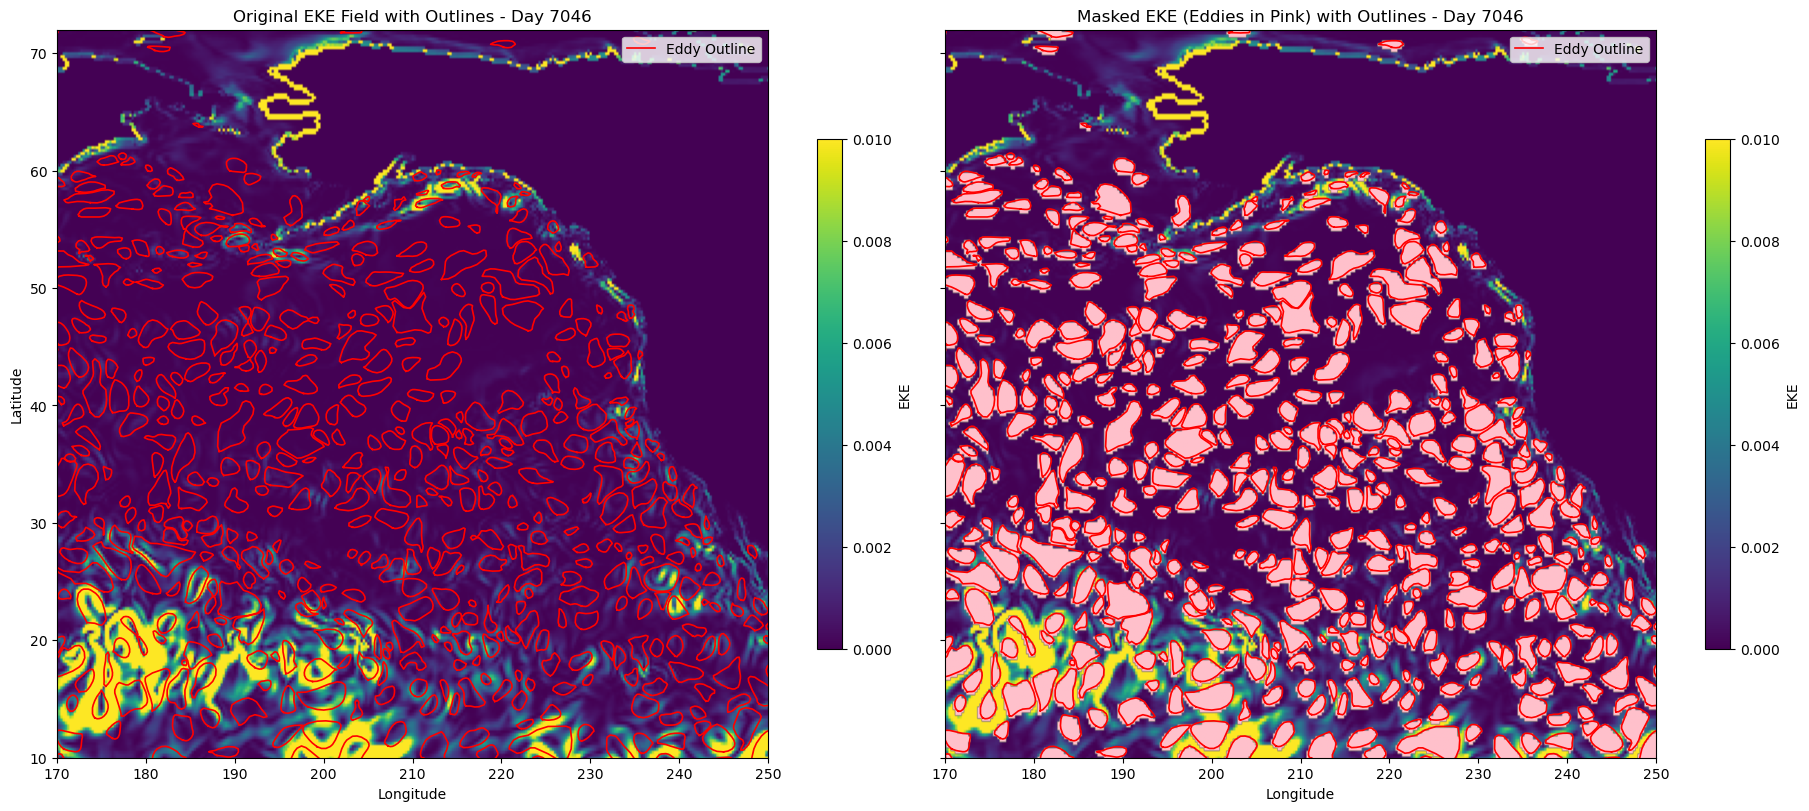

In [8]:


# 1. Load the generated NaN mask Zarr array directly
mask_zarr_path = "/scratch/b/b382618/eeke/NAN/non_eddy_nan_EKE_" + model + ".zarr"
mask_array = zarr.open(mask_zarr_path, mode='r')

# Load the original contour tracks to overlay the boundaries
path = "/scratch/b/b382618/eeke/" + "consolidated_tracks_reindexed_" + model + "_final.zarr" 
ds_tracks = zarr.open(path, mode='r')

# 2. Extract spatial dimensions
lons = icon_eke.lon.values
lats = icon_eke.lat.values
total_days = mask_array.shape[0]

# Pick a single random day from the processed range
np.random.seed(None) 
random_day_idx = np.random.randint(0, total_days)

# Extract the masked data slice for that random day
masked_day_data = mask_array[random_day_idx, :, :]

# Extract the original unmasked EKE data slice for the same day
original_day_data = icon_eke['EKE'].isel(time=random_day_idx).values

# Extract the raw boundary coordinates for this specific day
c_lons_raw = ds_tracks['effective_contour_longitude'][:, random_day_idx, :]
c_lats_raw = ds_tracks['effective_contour_latitude'][:, random_day_idx, :]
actual_num_eddies = c_lons_raw.shape[0]

# 3. Define the geographic viewing window (Gulf Stream Bounds)
lon_bounds = [170, 250]
lat_bounds = [10, 72]
extent = [lons.min(), lons.max(), lats.min(), lats.max()]

# 4. Generate the Side-by-Side Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True, constrained_layout=True)

# Define colormaps 
current_cmap = plt.colormaps['viridis'].copy()
current_cmap.set_bad(color='lightgray')

# Custom colormap to overlay pink onto the eddy NaNs explicitly
pink_cmap = ListedColormap(['pink'])

# Shared maximum data value for consistent comparison between plots
vmax_val = 0.01

# -----------------------------------------------------------------
# PANEL 1: Original EKE Field with Outlines
# -----------------------------------------------------------------
im1 = ax1.imshow(original_day_data, origin='lower', cmap=current_cmap, aspect='auto', 
                 extent=extent, vmin=0, vmax=vmax_val)

ax1.set_title(f"Original EKE Field with Outlines - Day {random_day_idx}")
ax1.set_xlim(lon_bounds)
ax1.set_ylim(lat_bounds)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
plt.colorbar(im1, ax=ax1, label='EKE', shrink=0.7)

# -----------------------------------------------------------------
# PANEL 2: Masked EKE Field (with Pink Eddy Interiors and Outlines)
# -----------------------------------------------------------------
im2 = ax2.imshow(masked_day_data, origin='lower', cmap=current_cmap, aspect='auto', 
                 extent=extent, vmin=0, vmax=vmax_val)

# Isolate the NaNs generated by the eddy mask logic
eddy_interior_mask = np.isnan(masked_day_data) & ~np.isnan(original_day_data)

# Overlay the solid pink color layer over the eddy interiors
ax2.imshow(np.where(eddy_interior_mask, 1, np.nan), origin='lower', 
          cmap=pink_cmap, aspect='auto', extent=extent, alpha=1.0)

ax2.set_title(f"Masked EKE (Eddies in Pink) with Outlines - Day {random_day_idx}")
ax2.set_xlabel("Longitude")
plt.colorbar(im2, ax=ax2, label='EKE', shrink=0.7)

# -----------------------------------------------------------------
# OVERLAY EDDY OUTLINES ON BOTH PANELS
# -----------------------------------------------------------------
label_added_ax1 = False
label_added_ax2 = False

for j in range(actual_num_eddies):
    clon, clat = c_lons_raw[j], c_lats_raw[j]
    
    if np.any(np.isnan(clon)):
        continue
        
    for offset in [-360, 0, 360]:
        adjusted_lon = clon + offset
        
        if np.any((adjusted_lon >= lon_bounds[0]) & (adjusted_lon <= lon_bounds[1])):
            # Handle label tracking for Panel 1 Legend
            lbl_ax1 = "Eddy Outline" if not label_added_ax1 else ""
            ax1.plot(adjusted_lon, clat, color='red', linewidth=1.2, label=lbl_ax1)
            if lbl_ax1:
                label_added_ax1 = True
            
            # Handle label tracking for Panel 2 Legend
            lbl_ax2 = "Eddy Outline" if not label_added_ax2 else ""
            ax2.plot(adjusted_lon, clat, color='red', linewidth=1.2, label=lbl_ax2)
            if lbl_ax2:
                label_added_ax2 = True
                
if label_added_ax1:
    ax1.legend(loc="upper right")
if label_added_ax2:
    ax2.legend(loc="upper right")
# -----------------------------------------------------------------

print(f"Displaying comparison diagnostic plot for random time index: {random_day_idx}")
plt.show()

**calculate the average over time**


Processing 8035 days incrementally to save memory...
Computing final nanmean from running totals...
Discarded 89 days out of 8035


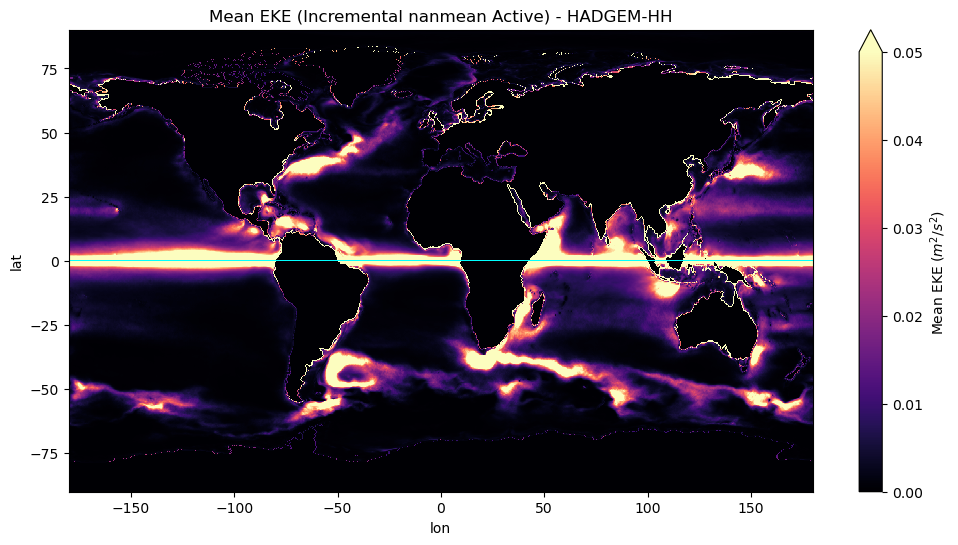

In [4]:

# 1. Open the Zarr array
eke_out_path = "/scratch/b/b382618/eeke/NAN/non_eddy_nan_EKE_" + model + ".zarr"
eke_store = zarr.open(eke_out_path, mode='r')
lons, lats = icon_eke.lon.values, icon_eke.lat.values
num_days, h, w = eke_store.shape

# 2. Initialize 2D arrays for tracking sum and count incrementally
# This avoids storing a massive 3D array in memory
running_sum = np.zeros((h, w), dtype=np.float32)
running_count = np.zeros((h, w), dtype=np.float32)
discarded_days = []

print(f"Processing {num_days} days incrementally to save memory...")

for i in range(num_days):
    # Load just ONE day into memory at a time
    slice_data = eke_store[i, :, :].astype(np.float32)
    
    # Check if the whole field is empty/zeroed out
    if np.all(np.isnan(slice_data)) or np.all(slice_data == 0):
        discarded_days.append(i)
        continue
    
    # Create a boolean mask of where this day has valid data
    valid_mask = ~np.isnan(slice_data)
    
    # Add the valid data to our running totals
    # np.add with where=valid_mask ignores the NaNs safely
    np.add(running_sum, slice_data, out=running_sum, where=valid_mask)
    np.add(running_count, 1.0, out=running_count, where=valid_mask)

# 3. Calculate final mean safely
print("Computing final nanmean from running totals...")

# Where running_count > 0, compute sum/count. Everywhere else, result is NaN.
mean_2d = np.divide(running_sum, running_count, out=np.full((h, w), np.nan, dtype=np.float32), where=running_count > 0)

print(f"Discarded {len(discarded_days)} days out of {num_days}")

# 4. Save and Plot
final_da = xr.DataArray(
    mean_2d,
    coords=[("lat", lats), ("lon", lons)],
    name="background_eke_nanmean"
)

final_da.to_netcdf("noneke_nanmean_" + model + "_mean_new.nc")

# Shift and Plot
final_da_shifted = final_da.assign_coords(lon=(((final_da.lon + 180) % 360) - 180)).sortby('lon')
current_cmap = copy.copy(plt.get_cmap('magma'))
current_cmap.set_bad(color='cyan') 

plt.figure(figsize=(12, 6))
final_da_shifted.plot(
    cmap=current_cmap, 
    vmin=0, 
    vmax=0.05, 
    robust=True,
    cbar_kwargs={'label': 'Mean EKE ($m^2/s^2$)'}
)

plt.title(f"Mean EKE (Incremental nanmean Active) - {model}")
plt.show()

### EDDY EKE NAN 

you don't need to rerun the first step (the one that takes 2-3h) if you already did it before. It uses the same dataset and just carries out the second step.

You use the same mask, just nan out all areas outside eddies. In previous step we nan-ed out eddy areas (hence, non-eddy intensity)

In [7]:


# 1. Open your ORIGINAL mask Zarr array (where eddy = NaN, outside = 1.0)
mask_zarr_path = "/scratch/b/b382618/eeke/NAN/non_eddy_nan_EKE_" + model + ".zarr"
mask_array = zarr.open(mask_zarr_path, mode='r')

print(f"The Zarr array shape is: {mask_array.shape}")
print(f"Number of time steps: {mask_array.shape[0]}")

# 2. Setup output EKE Zarr
start_day = 0
end_day = 8034 
num_days = (end_day - start_day) + 1

lons = icon_eke.lon.values
lats = icon_eke.lat.values
nlat, nlon = len(lats), len(lons)

eke_out_path = "/scratch/b/b382618/eeke/NAN/eddy_nan_EKE_" + model + ".zarr"

# Create the output array
eke_zarr_out = zarr.open(
    eke_out_path, 
    mode='w', 
    shape=(num_days, nlat, nlon), 
    chunks=(1, nlat, nlon), 
    dtype='f4'
)

print(f"Inverting masks from {mask_zarr_path} and applying to EKE...")

step_size = 100 
for start in range(0, num_days, step_size):
    end = min(start + step_size, num_days)
    print(f"Processing days {start} to {end-1}...")

    # A. Bulk load EKE values
    eke_block = icon_eke['EKE'].isel(time=slice(start, end)).values
    
    # B. Load the original mask block (eddy = NaN, outside = 1.0)
    mask_block = mask_array[start:end, :, :]
    
    # C. Invert the mask logic on the fly
    # Initialize an inverse mask block full of NaNs
    inverse_mask = np.full_like(mask_block, np.nan)
    
    # Where the original mask was NaN, make the inverse mask 1.0 (these are the eddies)
    inverse_mask[np.isnan(mask_block)] = 1.0
    
    # D. Apply the inverted mask to the EKE data
    eke_block = eke_block * inverse_mask
    
    # E. Write the final block
    eke_zarr_out[start:end, :, :] = eke_block

print("Eddy-only EKE Zarr generation complete")

The Zarr array shape is: (8035, 721, 1440)
Number of time steps: 8035
Inverting masks from /scratch/b/b382618/eeke/NAN/non_eddy_mask_with_EKEHADGEM-HH.zarr and applying to EKE...
Processing days 0 to 99...
Processing days 100 to 199...
Processing days 200 to 299...
Processing days 300 to 399...
Processing days 400 to 499...
Processing days 500 to 599...
Processing days 600 to 699...
Processing days 700 to 799...
Processing days 800 to 899...
Processing days 900 to 999...
Processing days 1000 to 1099...
Processing days 1100 to 1199...
Processing days 1200 to 1299...
Processing days 1300 to 1399...
Processing days 1400 to 1499...
Processing days 1500 to 1599...
Processing days 1600 to 1699...
Processing days 1700 to 1799...
Processing days 1800 to 1899...
Processing days 1900 to 1999...
Processing days 2000 to 2099...
Processing days 2100 to 2199...
Processing days 2200 to 2299...
Processing days 2300 to 2399...
Processing days 2400 to 2499...
Processing days 2500 to 2599...
Processing d

Displaying comparison diagnostic plot for random time index: 2033


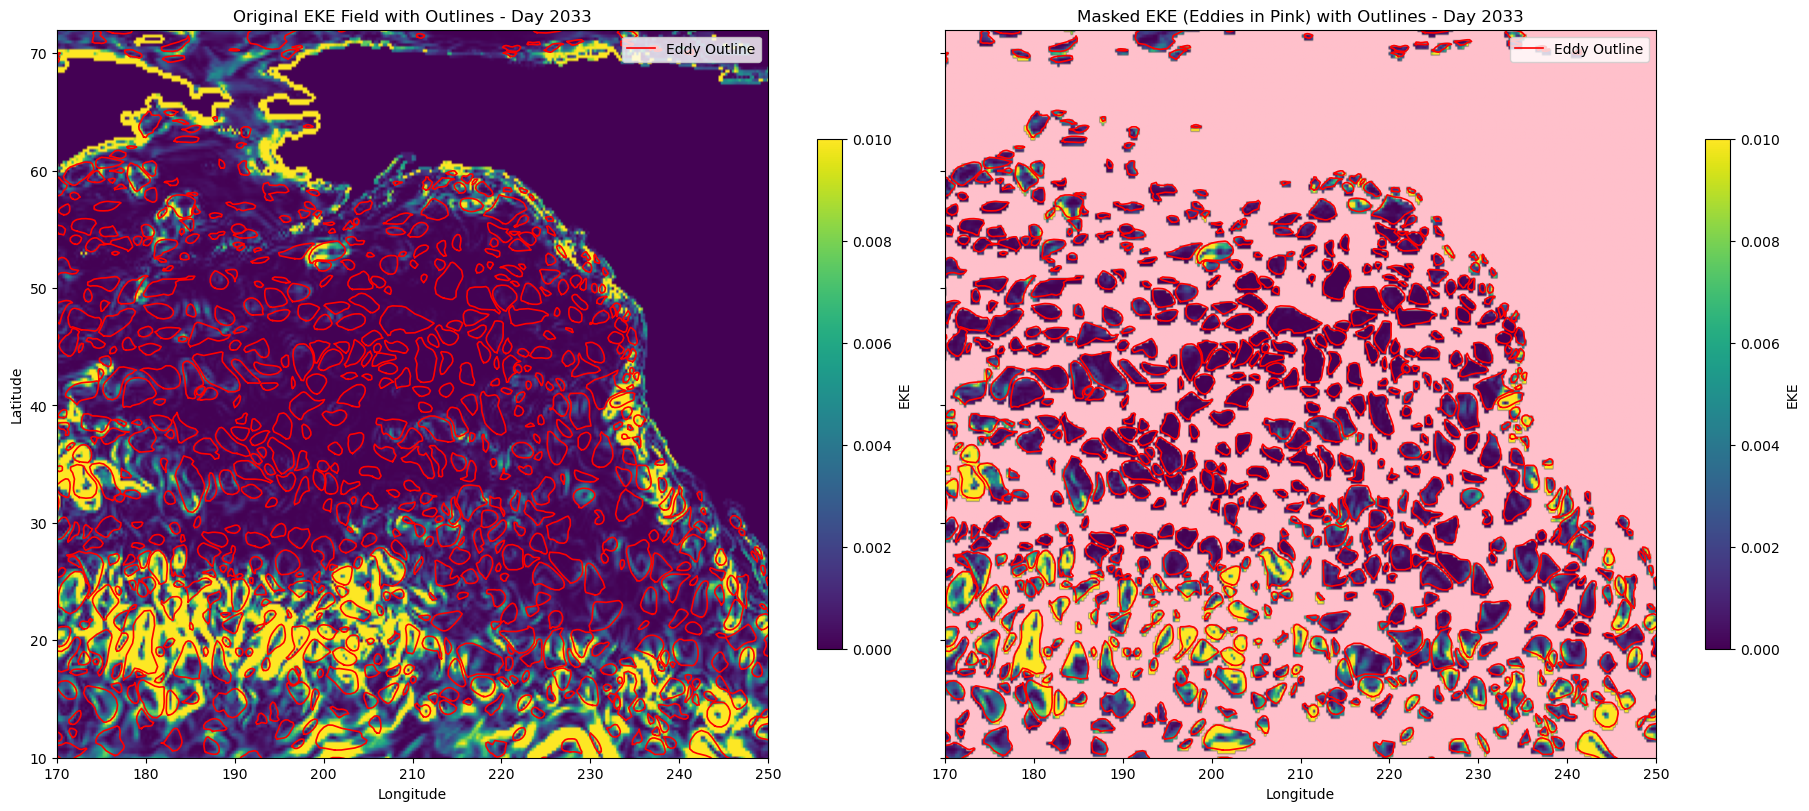

In [8]:


# 1. Load the generated NaN mask Zarr array directly
mask_zarr_path = "/scratch/b/b382618/eeke/NAN/eddy_nan_EKE_" + model + ".zarr"
mask_array = zarr.open(mask_zarr_path, mode='r')

# Load the original contour tracks to overlay the boundaries
path = "/scratch/b/b382618/eeke/" + "consolidated_tracks_reindexed_" + model + "_final.zarr" 
ds_tracks = zarr.open(path, mode='r')

# 2. Extract spatial dimensions
lons = icon_eke.lon.values
lats = icon_eke.lat.values
total_days = mask_array.shape[0]

# Pick a single random day from the processed range
np.random.seed(None) 
random_day_idx = np.random.randint(0, total_days)

# Extract the masked data slice for that random day
masked_day_data = mask_array[random_day_idx, :, :]

# Extract the original unmasked EKE data slice for the same day
original_day_data = icon_eke['EKE'].isel(time=random_day_idx).values

# Extract the raw boundary coordinates for this specific day
c_lons_raw = ds_tracks['effective_contour_longitude'][:, random_day_idx, :]
c_lats_raw = ds_tracks['effective_contour_latitude'][:, random_day_idx, :]
actual_num_eddies = c_lons_raw.shape[0]

# 3. Define the geographic viewing window (Gulf Stream Bounds)
lon_bounds = [170, 250]
lat_bounds = [10, 72]
extent = [lons.min(), lons.max(), lats.min(), lats.max()]

# 4. Generate the Side-by-Side Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True, constrained_layout=True)

# Define colormaps 
current_cmap = plt.colormaps['viridis'].copy()
current_cmap.set_bad(color='lightgray')

# Custom colormap to overlay pink onto the eddy NaNs explicitly
pink_cmap = ListedColormap(['pink'])

# Shared maximum data value for consistent comparison between plots
vmax_val = 0.01

# -----------------------------------------------------------------
# PANEL 1: Original EKE Field with Outlines
# -----------------------------------------------------------------
im1 = ax1.imshow(original_day_data, origin='lower', cmap=current_cmap, aspect='auto', 
                 extent=extent, vmin=0, vmax=vmax_val)

ax1.set_title(f"Original EKE Field with Outlines - Day {random_day_idx}")
ax1.set_xlim(lon_bounds)
ax1.set_ylim(lat_bounds)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
plt.colorbar(im1, ax=ax1, label='EKE', shrink=0.7)

# -----------------------------------------------------------------
# PANEL 2: Masked EKE Field (with Pink Eddy Interiors and Outlines)
# -----------------------------------------------------------------
im2 = ax2.imshow(masked_day_data, origin='lower', cmap=current_cmap, aspect='auto', 
                 extent=extent, vmin=0, vmax=vmax_val)

# Isolate the NaNs generated by the eddy mask logic
eddy_interior_mask = np.isnan(masked_day_data) & ~np.isnan(original_day_data)

# Overlay the solid pink color layer over the eddy interiors
ax2.imshow(np.where(eddy_interior_mask, 1, np.nan), origin='lower', 
          cmap=pink_cmap, aspect='auto', extent=extent, alpha=1.0)

ax2.set_title(f"Masked EKE (Eddies in Pink) with Outlines - Day {random_day_idx}")
ax2.set_xlabel("Longitude")
plt.colorbar(im2, ax=ax2, label='EKE', shrink=0.7)

# -----------------------------------------------------------------
# OVERLAY EDDY OUTLINES ON BOTH PANELS
# -----------------------------------------------------------------
label_added_ax1 = False
label_added_ax2 = False

for j in range(actual_num_eddies):
    clon, clat = c_lons_raw[j], c_lats_raw[j]
    
    if np.any(np.isnan(clon)):
        continue
        
    for offset in [-360, 0, 360]:
        adjusted_lon = clon + offset
        
        if np.any((adjusted_lon >= lon_bounds[0]) & (adjusted_lon <= lon_bounds[1])):
            # Handle label tracking for Panel 1 Legend
            lbl_ax1 = "Eddy Outline" if not label_added_ax1 else ""
            ax1.plot(adjusted_lon, clat, color='red', linewidth=1.2, label=lbl_ax1)
            if lbl_ax1:
                label_added_ax1 = True
            
            # Handle label tracking for Panel 2 Legend
            lbl_ax2 = "Eddy Outline" if not label_added_ax2 else ""
            ax2.plot(adjusted_lon, clat, color='red', linewidth=1.2, label=lbl_ax2)
            if lbl_ax2:
                label_added_ax2 = True
                
if label_added_ax1:
    ax1.legend(loc="upper right")
if label_added_ax2:
    ax2.legend(loc="upper right")
# -----------------------------------------------------------------

print(f"Displaying comparison diagnostic plot for random time index: {random_day_idx}")
plt.show()

**Calculate the average**

Processing 8035 days incrementally to save memory...
Computing final nanmean from running totals...
Discarded 89 days out of 8035


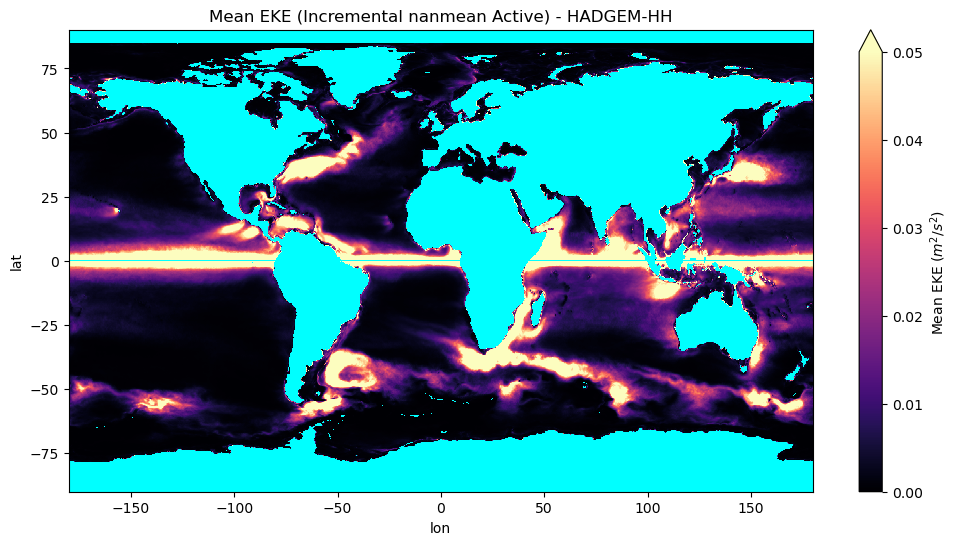

In [9]:


# 1. Open the Zarr array (Points to your eddy_mask_with_EKE Zarr)
eke_out_path = "/scratch/b/b382618/eeke/NAN/eddy_mask_with_EKE" + model + ".zarr"
eke_store = zarr.open(eke_out_path, mode='r')
lons, lats = icon_eke.lon.values, icon_eke.lat.values
num_days, h, w = eke_store.shape

# 2. Initialize 2D arrays for tracking sum and count incrementally
running_sum = np.zeros((h, w), dtype=np.float32)
running_count = np.zeros((h, w), dtype=np.float32)
discarded_days = []

print(f"Processing {num_days} days incrementally to save memory...")

for i in range(num_days):
    # Load just ONE day into memory at a time
    slice_data = eke_store[i, :, :].astype(np.float32)
    
    # Check if the whole field is empty/zeroed out
    if np.all(np.isnan(slice_data)) or np.all(slice_data == 0):
        discarded_days.append(i)
        continue
    
    # Create a boolean mask of where this day has valid data
    valid_mask = ~np.isnan(slice_data)
    
    # Add the valid data to our running totals
    # np.add with where=valid_mask ignores the NaNs safely
    np.add(running_sum, slice_data, out=running_sum, where=valid_mask)
    np.add(running_count, 1.0, out=running_count, where=valid_mask)

# 3. Calculate final mean safely
print("Computing final nanmean from running totals...")

# Where running_count > 0, compute sum/count. Everywhere else, result is NaN.
mean_2d = np.divide(running_sum, running_count, out=np.full((h, w), np.nan, dtype=np.float32), where=running_count > 0)

print(f"Discarded {len(discarded_days)} days out of {num_days}")

# 4. Save and Plot
final_da = xr.DataArray(
    mean_2d,
    coords=[("lat", lats), ("lon", lons)],
    name="background_eke_nanmean"
)

final_da.to_netcdf("eddy_nanmean_" + model + ".nc")

# Shift and Plot
final_da_shifted = final_da.assign_coords(lon=(((final_da.lon + 180) % 360) - 180)).sortby('lon')
current_cmap = copy.copy(plt.get_cmap('magma'))
current_cmap.set_bad(color='cyan') 

plt.figure(figsize=(12, 6))
final_da_shifted.plot(
    cmap=current_cmap, 
    vmin=0, 
    vmax=0.05, 
    robust=True,
    cbar_kwargs={'label': 'Mean EKE ($m^2/s^2$)'}
)

plt.title(f"Mean EKE (Incremental nanmean Active) - {model}")
plt.show()